In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
messy_timeseries_df = pd.read_csv("messy_timeseries.csv")
messy_timeseries_df

,timestamp,metric_value,site,notes,extra_column_int,extra_column_flag
0,2024-04-28,57.196,A,manual,32,True
1,2025-02-03,82.990,A,ok,73,False
2,2024-12-28,82.219,A,manual,97,True
3,2024-12-02,80.067,C,sensor?,12,False
4,2024-12-25,75.520,B,ok,92,False
...,...,...,...,...,...,...
423,2024-07-30,58.003,A,manual,18,True
424,2024-03-08,58.009,A,ok,22,True
425,2024/02/01,45.117,B,ok,57,False
426,2024-07-15,59.716,A,ok,17,False


- Note you can see the timestamp data is inconsistent (having dashes or slashes).  

In [3]:
messy_timeseries_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 428 entries, 0 to 427
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   timestamp          427 non-null    object 
 1   metric_value       410 non-null    float64
 2   site               428 non-null    object 
 3   notes              428 non-null    object 
 4   extra_column_int   428 non-null    int64  
 5   extra_column_flag  428 non-null    bool   
dtypes: bool(1), float64(1), int64(1), object(3)
memory usage: 17.3+ KB


In [4]:
messy_timeseries_df.head()

,timestamp,metric_value,site,notes,extra_column_int,extra_column_flag
0,2024-04-28,57.196,A,manual,32,True
1,2025-02-03,82.990,A,ok,73,False
2,2024-12-28,82.219,A,manual,97,True
3,2024-12-02,80.067,C,sensor?,12,False
4,2024-12-25,75.520,B,ok,92,False


In [5]:
messy_timeseries_df.describe()

,metric_value,extra_column_int
count,410.000000,428.000000
mean,64.849880,46.782710
std,48.391797,28.548032
min,-120.000000,0.000000
25%,54.474750,22.000000
50%,60.392000,45.000000
75%,72.026250,72.000000
max,999.000000,99.000000


- Note: Outlier with the min value being negative.

In [6]:
messy_timeseries_df['site'].value_counts()

A    214
B    130
C     84
Name: site, dtype: int64

In [7]:
messy_timeseries_df['extra_column_int'].value_counts()

32    11
45     9
46     8
28     8
75     8
      ..
51     2
90     1
59     1
54     1
78     1
Name: extra_column_int, Length: 98, dtype: int64

In [8]:
messy_timeseries_df['timestamp'].isna().value_counts()

False    427
True       1
Name: timestamp, dtype: int64

- Note: Missing values for 'timestamp'

In [9]:
messy_timeseries_df.isna().value_counts()

timestamp  metric_value  site   notes  extra_column_int  extra_column_flag
False      False         False  False  False             False                409
           True          False  False  False             False                 18
True       False         False  False  False             False                  1
dtype: int64

- Note: Missing values for 'timestamp' and 'metric_value'

In [10]:
messy_timeseries_df.duplicated().value_counts()

False    428
dtype: int64

In [11]:
messy_timeseries_df['timestamp'].iloc[46]

'not_a_date'

In [12]:
messy_timeseries_df.drop(index=46, inplace=True)
messy_timeseries_df['timestamp'].iloc[46]

'2025-02-15'

Dropped the missing value for 'timestamp'.

In [13]:
messy_timeseries_df['timestamp'].isna().value_counts()

False    426
True       1
Name: timestamp, dtype: int64

In [14]:
messy_timeseries_df.isna().sum()

timestamp             1
metric_value         18
site                  0
notes                 0
extra_column_int      0
extra_column_flag     0
dtype: int64

In [15]:
messy_timeseries_df.dropna(subset=['timestamp'],inplace=True)
messy_timeseries_df.isna().sum()

timestamp             0
metric_value         18
site                  0
notes                 0
extra_column_int      0
extra_column_flag     0
dtype: int64

Drop the row with na value from column 'timestamp'.

In [16]:
messy_timeseries_df['timestamp'] = pd.to_datetime(messy_timeseries_df['timestamp'])
messy_timeseries_df['timestamp'] = messy_timeseries_df['timestamp'].dt.strftime('%Y-%m-%d')
messy_timeseries_df['timestamp'] = pd.to_datetime(messy_timeseries_df['timestamp'])
messy_timeseries_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 426 entries, 0 to 427
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   timestamp          426 non-null    datetime64[ns]
 1   metric_value       408 non-null    float64       
 2   site               426 non-null    object        
 3   notes              426 non-null    object        
 4   extra_column_int   426 non-null    int64         
 5   extra_column_flag  426 non-null    bool          
dtypes: bool(1), datetime64[ns](1), float64(1), int64(1), object(2)
memory usage: 20.4+ KB


Change the 'timestamp' object type to datetime type. Also, format the datetime in '%Y-%m-%d'.

In [17]:
messy_timeseries_df

,timestamp,metric_value,site,notes,extra_column_int,extra_column_flag
0,2024-04-28,57.196,A,manual,32,True
1,2025-02-03,82.990,A,ok,73,False
2,2024-12-28,82.219,A,manual,97,True
3,2024-12-02,80.067,C,sensor?,12,False
4,2024-12-25,75.520,B,ok,92,False
...,...,...,...,...,...,...
423,2024-07-30,58.003,A,manual,18,True
424,2024-03-08,58.009,A,ok,22,True
425,2024-02-01,45.117,B,ok,57,False
426,2024-07-15,59.716,A,ok,17,False


In [18]:
messy_timeseries_df['metric_value'].isna().sum()

18

In [19]:
avg_metric_value = messy_timeseries_df['metric_value'].mean()
messy_timeseries_df['metric_value'].fillna(avg_metric_value, inplace=True)
messy_timeseries_df['metric_value'].isna().sum()

0

In [20]:
messy_timeseries_df.describe()

,metric_value,extra_column_int
count,426.000000,426.000000
mean,64.896904,46.863850
std,47.465411,28.568024
min,-120.000000,0.000000
25%,55.029500,22.000000
50%,61.334000,45.000000
75%,71.788250,72.000000
max,999.000000,99.000000


Above code I replaced missing 'metric_value' with their avg. 'metric_value'.

In [21]:
# sort data by time
sorted_timeseries_df = messy_timeseries_df.sort_values(by='timestamp')
sorted_timeseries_df

,timestamp,metric_value,site,notes,extra_column_int,extra_column_flag
406,2024-01-01,50.762,B,ok,76,True
263,2024-01-02,48.695,C,ok,23,False
39,2024-01-03,54.412,A,ok,76,False
66,2024-01-04,56.021,B,sensor?,10,False
360,2024-01-05,49.772,A,sensor?,48,False
...,...,...,...,...,...,...
197,2025-02-19,75.107,A,ok,97,False
383,2025-02-20,78.121,A,ok,34,True
55,2025-02-21,79.697,B,sensor?,7,False
143,2025-02-22,77.339,C,ok,37,False


TODO: Detect outliers using IQR or z-score and decide:
    
    •	Remove them
    •	Cap them (winsorize)
    •	Keep them (with strong justification)


In [22]:
from scipy import stats

In [23]:
# Detect outliers using z-score for metric_value:
sorted_timeseries_df['metric_value_zscore'] = np.abs(stats.zscore(sorted_timeseries_df['metric_value'])) 
outliers_z = sorted_timeseries_df[sorted_timeseries_df['metric_value_zscore'] > 3]
print("Outliers (Z-score):\n", outliers_z)

Outliers (Z-score):
      timestamp  metric_value site    notes  extra_column_int  \
405 2024-03-16         999.0    A       ok                15   
8   2024-08-28        -120.0    A  sensor?                60   

     extra_column_flag  metric_value_zscore  
405              False            19.702798  
8                False             3.899983  


 - You can tell there are about 19 outliers for metric_value. I decide to remove these outliers. By filtering them out <= 3

In [24]:
# Filter out the outliers:
clean_timeseries_df = sorted_timeseries_df[sorted_timeseries_df['metric_value_zscore'] <= 3]
outliers_z2 = clean_timeseries_df[clean_timeseries_df['metric_value_zscore'] > 3]
print("Outliers (Z-score):\n", outliers_z2)
clean_timeseries_df

Outliers (Z-score):
 Empty DataFrame
Columns: [timestamp, metric_value, site, notes, extra_column_int, extra_column_flag, metric_value_zscore]
Index: []


,timestamp,metric_value,site,notes,extra_column_int,extra_column_flag,metric_value_zscore
406,2024-01-01,50.762,B,ok,76,True,0.298144
263,2024-01-02,48.695,C,ok,23,False,0.341743
39,2024-01-03,54.412,A,ok,76,False,0.221155
66,2024-01-04,56.021,B,sensor?,10,False,0.187217
360,2024-01-05,49.772,A,sensor?,48,False,0.319026
...,...,...,...,...,...,...,...
197,2025-02-19,75.107,A,ok,97,False,0.215359
383,2025-02-20,78.121,A,ok,34,True,0.278932
55,2025-02-21,79.697,B,sensor?,7,False,0.312175
143,2025-02-22,77.339,C,ok,37,False,0.262438


- Most of the zscore values are at the mean.

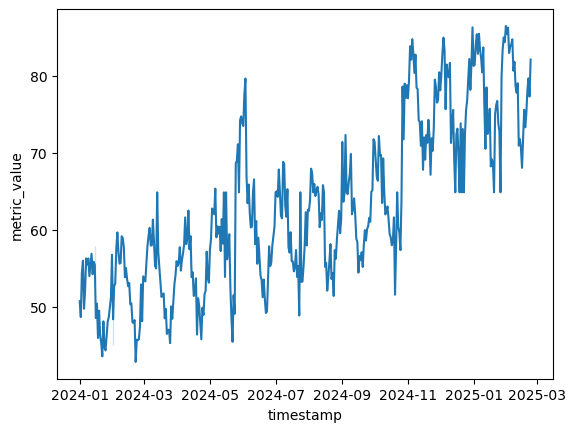

In [25]:
sns.lineplot(data=clean_timeseries_df, x='timestamp', y='metric_value')
plt.show()

- Time series plot showing trend among the metric_value. You can see that the metric_value often increases and decreases. Yearly increases.

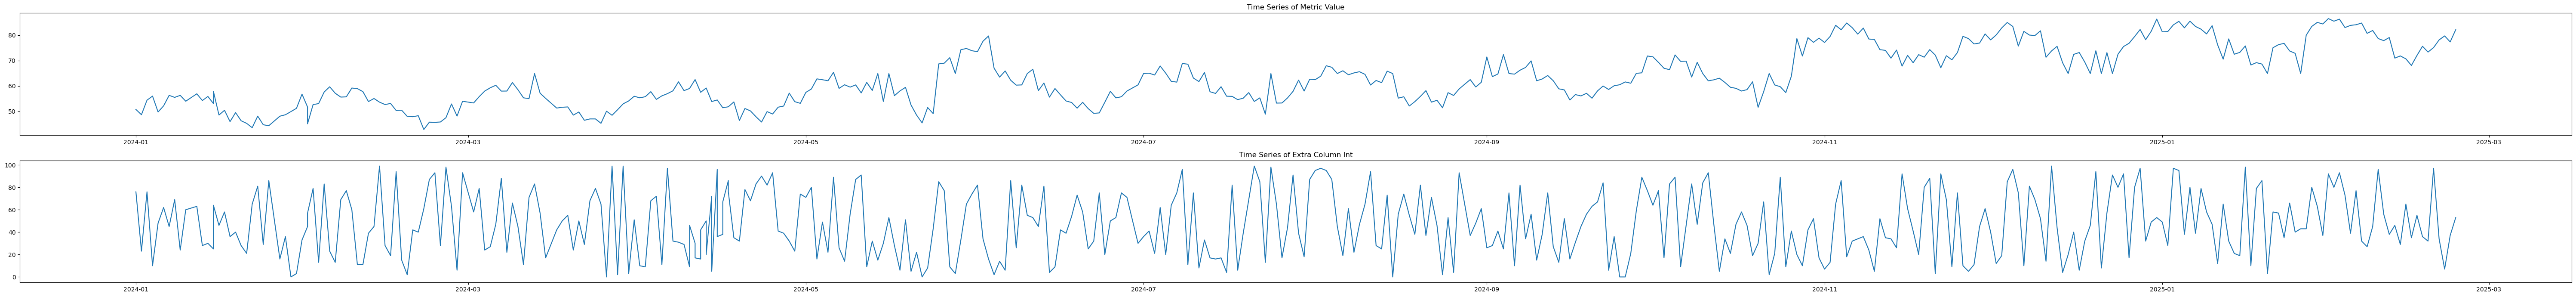

In [26]:
fig, ax = plt.subplots(2,1,figsize=(60, 7))
ax[0].plot(clean_timeseries_df['timestamp'], clean_timeseries_df['metric_value'])
ax[0].set_title('Time Series of Metric Value')
ax[1].plot(clean_timeseries_df['timestamp'], clean_timeseries_df['extra_column_int'])
ax[1].set_title('Time Series of Extra Column Int')
plt.tight_layout()
plt.show()



- Two time series plots show the increase and decrease of the two numerical values. You can see that the metric value increases each year. A risk with this data plot is the upward movement could be mistaken for sustained long-term growth when it may partly reflect seasonality or external factors, not a structural increase. Another risk for the second plot, The random spikes could be misread as meaningful patterns or trends, when they may simply reflect noise or short-term fluctuations rather than systematic change.

C:\Users\sydne\AppData\Local\Temp\ipykernel_132420\3913021511.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_timeseries_df['std_metric_value'] = clean_timeseries_df['metric_value'].std()


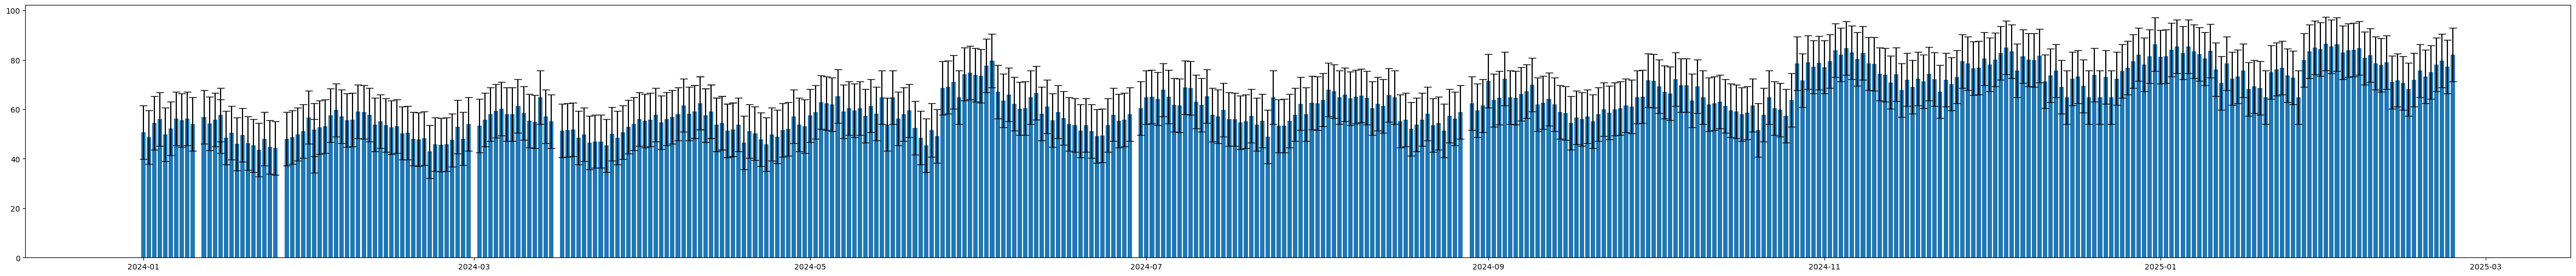

In [27]:
plt.figure(figsize=(60, 6))
# std of metric value
clean_timeseries_df['std_metric_value'] = clean_timeseries_df['metric_value'].std()
# bar plot with error bars
plt.bar(clean_timeseries_df['timestamp'], clean_timeseries_df['metric_value'], yerr=clean_timeseries_df['std_metric_value'], capsize=5)
plt.show()

- The metric values fluctuate over time but show an overall upward trend. The error bars appear uniform across all timestamps (same height), indicating a constant standard deviation applied to every bar rather than time-specific variability. A risk, the same global standard deviation is used for every timestamp, the error bars may falsely suggest that variability is identical at all time points. This can mislead viewers into thinking uncertainty is constant over time, masking periods of higher or lower volatility.

In [28]:
clean_timeseries_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 424 entries, 406 to 355
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   timestamp            424 non-null    datetime64[ns]
 1   metric_value         424 non-null    float64       
 2   site                 424 non-null    object        
 3   notes                424 non-null    object        
 4   extra_column_int     424 non-null    int64         
 5   extra_column_flag    424 non-null    bool          
 6   metric_value_zscore  424 non-null    float64       
 7   std_metric_value     424 non-null    float64       
dtypes: bool(1), datetime64[ns](1), float64(3), int64(1), object(2)
memory usage: 26.9+ KB


C:\Users\sydne\AppData\Local\Temp\ipykernel_132420\299949224.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_timeseries_df['month'] = clean_timeseries_df['timestamp'].dt.month_name()


<Axes: xlabel='month', ylabel='Count'>

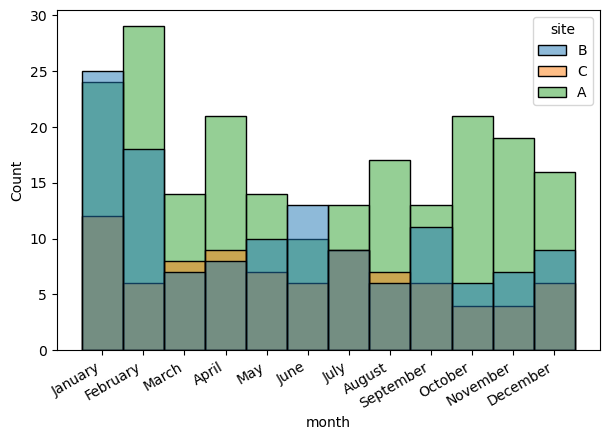

In [32]:
# Seasonal aggregation by month for each site:
fig, ax = plt.subplots(figsize=(7, 5))
clean_timeseries_df['month'] = clean_timeseries_df['timestamp'].dt.month_name()
fig.autofmt_xdate()
sns.histplot(data=clean_timeseries_df, x='month', hue='site')

- The plot reveals seasonal variation across sites, with Site A showing higher activity in several months. However, since this visualization displays record counts rather than aggregated metric values, differences may reflect unequal data frequency rather than true performance differences.

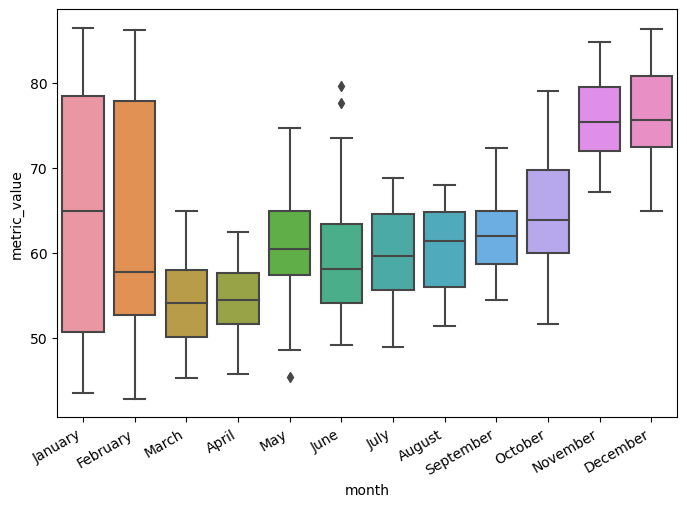

In [33]:
# Distribution view across time buckets using boxplot:
fig, ax = plt.subplots(figsize=(8, 6))
fig.autofmt_xdate()
sns.boxplot(data=clean_timeseries_df, x='month', y='metric_value')
plt.show()

- Plot displays the monthly values of the metric value. December having the highest metric value. A risk this graph shows is there are two outliers for June and 1 outlier for May; showing infrequentcies with the data.

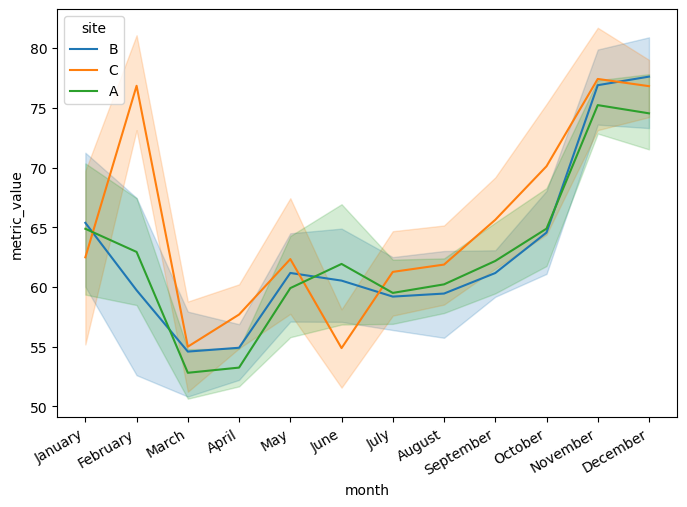

In [36]:
# What is the trend among each site and its metric_value?
fig, ax = plt.subplots(figsize=(8, 6))
fig.autofmt_xdate()
sns.lineplot(data=clean_timeseries_df, x='month', y='metric_value', hue='site', palette='tab10')
plt.show()

- Based off the visual you can see that site C metric_value increases as the two sites decrease (Negative Correlation). When site C decreases the two sites increase (Negative Correlation). For January and December, site C saw some increases in metric_value. Also, between April and May there were increases for site C. In June site C decreased at its lowest point, while the other two sites saw an increase. A risk this data has is the display of Negative Correlation with site C compared to the other two sites.